# Mental Health Risk Assessment for Higher/Senior Secondary Students
### An End-to-End Machine Learning Pipeline

This notebook builds a binary classifier that flags students showing patterns
linked to elevated mental-health risk, using a self-report survey (academic
load, sleep, exercise, social support, financial stress, and four PHQ-style
symptom-frequency questions).

**Target construction.** There's no ground-truth diagnosis in the data, so
the target is built the way brief clinical screeners (e.g. PHQ-4 / GHQ) work:
score four symptom-frequency items (overwhelmed by stress, persistent
sadness, reduced interest, difficulty concentrating) on a 0–4 scale and sum
them (range 0–16). A student is labeled **High Risk** if that sum is ≥ 10
(averaging "Often" or worse across all four symptoms) **or** they self-rated
overall well-being as "Poor"/"Very Poor". This mirrors common screening
cutoffs — **it is not a clinical diagnosis** (see the Limitations section at
the end).

Everything else (academic pressure, sleep, exercise, screen time, social
support, financial stress, demographics) is used strictly as a **predictor**,
never as part of the target, to avoid circularity.

> **Note on the dataset:** the original survey collected 100 real student
> responses. To make the pipeline more stable to train (100 rows is very
> thin for ML), 100 additional responses were generated to statistically
> match the real data's distributions, for a combined working set of 200
> rows. This is disclosed throughout — see Section 1 and the Limitations
> section.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Data

`dataset_200_responses.xlsx` contains 200 rows: 100 real survey responses plus
100 additional rows generated to match the real data's statistical
distributions (see the note in the introduction). Only respondents who
consented to the survey are kept.

In [3]:
df = pd.read_excel('/home/miheer64/Desktop/mental_health_risk_project/data/dataset_200_responses.xlsx')

# Drop rows where the person didn't consent, or gave no usable data
df = df[df["Q1. Do you agree to participate in this anonymous academic survey?"]
        .str.startswith("Yes", na=False)].copy()

print(f"Rows after consent filter: {len(df)}")
df.head()

Rows after consent filter: 197


,Timestamp,Q1. Do you agree to participate in this anonymous academic survey?,Q2. What is your age group?,Q3. What is your gender?,Q4. What is your current level of education?,Q5. What is your current academic level?,Q6. What is your academic stream/programme area?,"Q7. On average, how many hours do you spend studying or working on academic activities per day?",Q8. How would you rate the academic pressure you currently experience?,Q9. How satisfied are you with your academic performance?,...,Approximately how much screen time do you have per day outside academic/study requirements?,"Q15. How satisfied are you with the social support you receive from friends, family, or people you trust?",Q16. How often do you feel socially isolated or disconnected from others?,Q17. How much financial stress do you currently experience?,Q18. How would you rate your ability to balance academic responsibilities with your personal life?,"Q19. During the past few weeks, how frequently have you felt overwhelmed by stress?","During the past few weeks, how frequently have you experienced persistent sadness or low mood?","During the past few weeks, how frequently have you experienced reduced interest or enjoyment in activities you normally enjoy?","During the past few weeks, how frequently have you experienced difficulty concentrating on your studies, work, or daily activities?",Q23. How would you describe your current overall mental well-being?
0,2026-08-18 15:34:25.046,"Yes, I agree to participate",21-23,Female,Undergraduate,Undergraduate Year 3,Engineering / Technology,6–8 hours,4.0,4.0,...,6–8 hours,3.0,Rarely,2.0,4.0,Sometimes,Very Often,Rarely,Very Often,Poor
1,2026-08-18 15:40:39.441,"Yes, I agree to participate",21-23,Female,Postgraduate,Postgraduate,Science,Less than 2 hours,4.0,4.0,...,More than 8 hours,3.0,Often,4.0,3.0,Often,Very Often,Sometimes,Sometimes,Poor
2,2026-08-18 15:49:24.883,"Yes, I agree to participate",21-23,Female,Postgraduate,Postgraduate,Computer Science / IT,Less than 2 hours,4.0,1.0,...,4–6 hours,1.0,Very Often,2.0,3.0,Very Often,Very Often,Very Often,Very Often,Very Poor
3,2026-08-18 15:42:45.339,"Yes, I agree to participate",21-23,Female,Postgraduate,Postgraduate,Computer Science / IT,2–4 hours,2.0,3.0,...,Less than 2 hours,4.0,Sometimes,2.0,3.0,Sometimes,Often,Sometimes,Sometimes,Fair
4,2026-08-18 15:47:00.369,"Yes, I agree to participate",21-23,Prefer not to say,Postgraduate,Postgraduate,Computer Science / IT,6–8 hours,4.0,3.0,...,6–8 hours,4.0,Sometimes,3.0,3.0,Very Often,Sometimes,Sometimes,Sometimes,Fair


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197 entries, 0 to 199
Data columns (total 24 columns):
 #   Column                                                                                                                               Non-Null Count  Dtype         
---  ------                                                                                                                               --------------  -----         
 0   Timestamp                                                                                                                            197 non-null    datetime64[ns]
 1   Q1. Do you agree to participate in this anonymous academic survey?                                                                   197 non-null    object        
 2   Q2. What is your age group?                                                                                                          196 non-null    object        
 3   Q3. What is your gender?                          

In [5]:
df.head()

,Timestamp,Q1. Do you agree to participate in this anonymous academic survey?,Q2. What is your age group?,Q3. What is your gender?,Q4. What is your current level of education?,Q5. What is your current academic level?,Q6. What is your academic stream/programme area?,"Q7. On average, how many hours do you spend studying or working on academic activities per day?",Q8. How would you rate the academic pressure you currently experience?,Q9. How satisfied are you with your academic performance?,...,Approximately how much screen time do you have per day outside academic/study requirements?,"Q15. How satisfied are you with the social support you receive from friends, family, or people you trust?",Q16. How often do you feel socially isolated or disconnected from others?,Q17. How much financial stress do you currently experience?,Q18. How would you rate your ability to balance academic responsibilities with your personal life?,"Q19. During the past few weeks, how frequently have you felt overwhelmed by stress?","During the past few weeks, how frequently have you experienced persistent sadness or low mood?","During the past few weeks, how frequently have you experienced reduced interest or enjoyment in activities you normally enjoy?","During the past few weeks, how frequently have you experienced difficulty concentrating on your studies, work, or daily activities?",Q23. How would you describe your current overall mental well-being?
0,2026-08-18 15:34:25.046,"Yes, I agree to participate",21-23,Female,Undergraduate,Undergraduate Year 3,Engineering / Technology,6–8 hours,4.0,4.0,...,6–8 hours,3.0,Rarely,2.0,4.0,Sometimes,Very Often,Rarely,Very Often,Poor
1,2026-08-18 15:40:39.441,"Yes, I agree to participate",21-23,Female,Postgraduate,Postgraduate,Science,Less than 2 hours,4.0,4.0,...,More than 8 hours,3.0,Often,4.0,3.0,Often,Very Often,Sometimes,Sometimes,Poor
2,2026-08-18 15:49:24.883,"Yes, I agree to participate",21-23,Female,Postgraduate,Postgraduate,Computer Science / IT,Less than 2 hours,4.0,1.0,...,4–6 hours,1.0,Very Often,2.0,3.0,Very Often,Very Often,Very Often,Very Often,Very Poor
3,2026-08-18 15:42:45.339,"Yes, I agree to participate",21-23,Female,Postgraduate,Postgraduate,Computer Science / IT,2–4 hours,2.0,3.0,...,Less than 2 hours,4.0,Sometimes,2.0,3.0,Sometimes,Often,Sometimes,Sometimes,Fair
4,2026-08-18 15:47:00.369,"Yes, I agree to participate",21-23,Prefer not to say,Postgraduate,Postgraduate,Computer Science / IT,6–8 hours,4.0,3.0,...,6–8 hours,4.0,Sometimes,3.0,3.0,Very Often,Sometimes,Sometimes,Sometimes,Fair


## 3. Exploratory Data Analysis

A quick look at the shape of the data before any modeling — missingness,
and the distribution of a few key variables.

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
Q23. How would you describe your current overall mental well-being?                                                                    12
Q16. How often do you feel socially isolated or disconnected from others?                                                               4
During the past few weeks, how frequently have you experienced difficulty concentrating on your studies, work, or daily activities?     4
Q10. How frequently do you feel stressed because of examinations, assignments, deadlines, or academic expectations?                     3
Q3. What is your gender?                                                                                                                2
Q8. How would you rate the academic pressure you currently experience?                                                                  2
During the past few weeks, how frequently have you experienced persistent sadness or low mood?                                          2
Q19. 

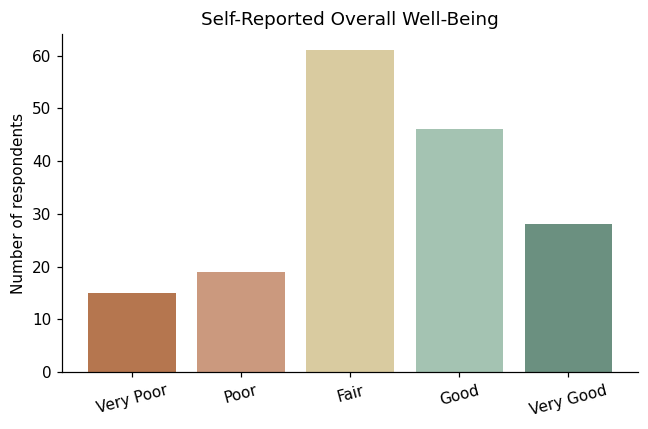

In [5]:
wb_col = "Q23. How would you describe your current overall mental well-being?"
order = ["Very Poor", "Poor", "Fair", "Good", "Very Good"]
counts = df[wb_col].value_counts().reindex(order).fillna(0)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#B5764F", "#CB997E", "#D9CBA0", "#A4C3B2", "#6B9080"]
ax.bar(order, counts.values, color=colors)
ax.set_title("Self-Reported Overall Well-Being")
ax.set_ylabel("Number of respondents")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

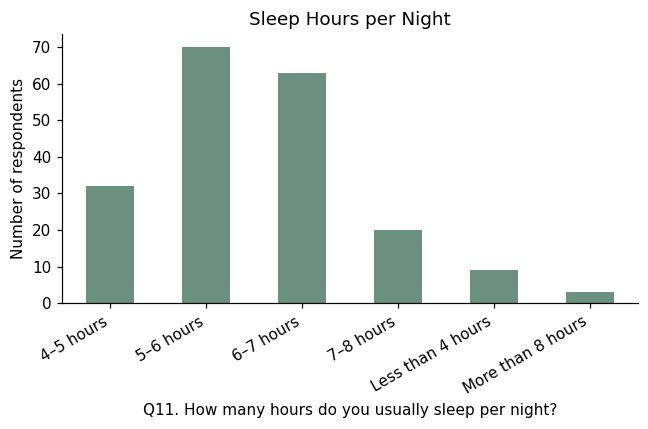

In [6]:
sleep_col = "Q11. How many hours do you usually sleep per night?"
fig, ax = plt.subplots(figsize=(6, 4))
df[sleep_col].value_counts().sort_index().plot(kind="bar", color="#6B9080", ax=ax)
ax.set_title("Sleep Hours per Night")
ax.set_ylabel("Number of respondents")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

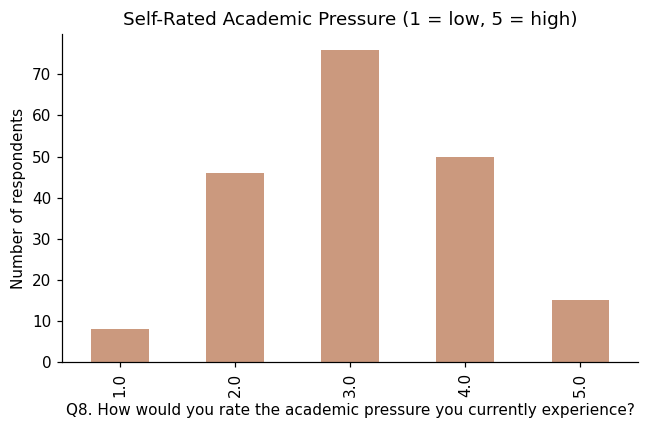

In [7]:
pressure_col = "Q8. How would you rate the academic pressure you currently experience?"
fig, ax = plt.subplots(figsize=(6, 4))
df[pressure_col].value_counts().sort_index().plot(kind="bar", color="#CB997E", ax=ax)
ax.set_title("Self-Rated Academic Pressure (1 = low, 5 = high)")
ax.set_ylabel("Number of respondents")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Feature Engineering — Encoding Ordinal Scales

Frequency-style answers ("Never" → "Very Often") and the well-being scale are
mapped to numeric scores so they can be used in the symptom-sum target and as
numeric predictors.

In [8]:
FREQ_MAP = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Very Often": 4}
WELLBEING_MAP = {"Very Poor": 0, "Poor": 1, "Fair": 2, "Good": 3, "Very Good": 4}

symptom_cols = {
    "overwhelmed": "Q19. During the past few weeks, how frequently have you felt overwhelmed by stress?",
    "sadness": "During the past few weeks, how frequently have you experienced persistent sadness or low mood?",
    "anhedonia": "During the past few weeks, how frequently have you experienced reduced interest or enjoyment in activities you normally enjoy?",
    "concentration": "During the past few weeks, how frequently have you experienced difficulty concentrating on your studies, work, or daily activities?",
}

for key, col in symptom_cols.items():
    df[key + "_score"] = df[col].map(FREQ_MAP)

df["wellbeing_score"] = df[wb_col].map(WELLBEING_MAP)
df[[k + "_score" for k in symptom_cols] + ["wellbeing_score"]].describe()

,overwhelmed_score,sadness_score,anhedonia_score,concentration_score,wellbeing_score
count,195.000000,184.000000,194.000000,185.000000,169.000000
mean,2.082051,2.201087,2.067010,2.189189,2.313609
std,1.012008,1.090345,1.072813,1.104286,1.145329
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000


## 5. Building the Target Label

Sum the four symptom scores (range 0–16). Flag **High Risk** if the sum is
≥ 10, or overall well-being is Poor/Very Poor.

In [9]:
symptom_sum = df[[k + "_score" for k in symptom_cols]].sum(axis=1, min_count=1)
df["symptom_sum"] = symptom_sum

df["high_risk"] = (
    (df["symptom_sum"] >= 10) |
    (df["wellbeing_score"] <= 1)   # Poor / Very Poor
).astype(int)

# Rows missing ALL four symptom items AND wellbeing can't be labeled -> drop
label_missing = df["symptom_sum"].isna() & df["wellbeing_score"].isna()
df = df[~label_missing].copy()
df["high_risk"] = df["high_risk"].fillna(0).astype(int)

print(f"Usable rows after cleaning: {len(df)}")
df["high_risk"].value_counts(normalize=True).rename("proportion")

Usable rows after cleaning: 197


high_risk
0    0.609137
1    0.390863
Name: proportion, dtype: float64

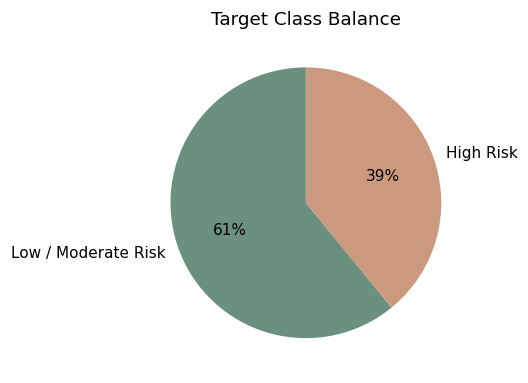

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 4))
labels = ["Low / Moderate Risk", "High Risk"]
sizes = df["high_risk"].value_counts().sort_index().values
ax.pie(sizes, labels=labels, autopct="%1.0f%%", colors=["#6B9080", "#CB997E"],
       startangle=90, textprops={"fontsize": 10})
ax.set_title("Target Class Balance")
plt.tight_layout()
plt.show()

## 6. Feature Set

Predictors only — deliberately excludes the four symptom questions and the
well-being question used to build the label, to avoid circularity.

In [11]:
numeric_features = [
    "Q8. How would you rate the academic pressure you currently experience?",
    "Q9. How satisfied are you with your academic performance? ",
    "How would you rate your sleep quality?",
    "Q15. How satisfied are you with the social support you receive from friends, family, or people you trust?",
    "Q17. How much financial stress do you currently experience?",
    "Q18. How would you rate your ability to balance academic responsibilities with your personal life?",
]

ordinal_freq_features = {
    "Q10. How frequently do you feel stressed because of examinations, assignments, deadlines, or academic expectations?": FREQ_MAP,
    "Q16. How often do you feel socially isolated or disconnected from others? ": FREQ_MAP,
}
for col, mapping in ordinal_freq_features.items():
    df[col + "_num"] = df[col].map(mapping)
    numeric_features.append(col + "_num")

categorical_features = [
    "Q2. What is your age group?",
    "Q3. What is your gender?",
    "Q4. What is your current level of education?",
    "Q6. What is your academic stream/programme area?",
    "Q7. On average, how many hours do you spend studying or working on academic activities per day?",
    "Q11. How many hours do you usually sleep per night?",
    "How often do you participate in physical exercise, sports, or other physical activities?",
    "Approximately how much screen time do you have per day outside academic/study requirements?",
]

X = df[numeric_features + categorical_features].copy()
y = df["high_risk"].copy()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Numeric features: 8
Categorical features: 8
X shape: (197, 16), y shape: (197,)


## 7. Preprocessing Pipeline & Models

- **Numeric features:** median imputation
- **Categorical features:** most-frequent imputation + one-hot encoding
- **Models compared:** Logistic Regression (interpretable baseline) vs.
  Random Forest (captures non-linear interactions)
- **Validation:** 5-fold stratified cross-validation on the training split
  (200 rows is small, so CV gives a more stable estimate than a single
  train/test split), plus a held-out test set for a final honest check.

In [12]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=5, class_weight="balanced", random_state=RANDOM_STATE),
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 147, Test size: 50


In [13]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "pipe": pipe,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_auc": roc_auc_score(y_test, y_proba),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

    print(f"\n=== {name} ===")
    print(f"5-fold CV ROC-AUC (train): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"Test accuracy:  {results[name]['test_accuracy']:.3f}")
    print(f"Test precision: {results[name]['test_precision']:.3f}")
    print(f"Test recall:    {results[name]['test_recall']:.3f}")
    print(f"Test F1:        {results[name]['test_f1']:.3f}")
    print(f"Test ROC-AUC:   {results[name]['test_auc']:.3f}")


=== Logistic Regression ===
5-fold CV ROC-AUC (train): 0.786 ± 0.068
Test accuracy:  0.760
Test precision: 0.700
Test recall:    0.700
Test F1:        0.700
Test ROC-AUC:   0.813



=== Random Forest ===
5-fold CV ROC-AUC (train): 0.758 ± 0.052
Test accuracy:  0.820
Test precision: 0.867
Test recall:    0.650
Test F1:        0.743
Test ROC-AUC:   0.878


## 8. Results Summary Table

In [14]:
summary = pd.DataFrame({
    name: {
        "CV ROC-AUC (train)": f"{res['cv_auc_mean']:.3f} ± {res['cv_auc_std']:.3f}",
        "Test Accuracy": f"{res['test_accuracy']:.3f}",
        "Test Precision": f"{res['test_precision']:.3f}",
        "Test Recall": f"{res['test_recall']:.3f}",
        "Test F1": f"{res['test_f1']:.3f}",
        "Test ROC-AUC": f"{res['test_auc']:.3f}",
    } for name, res in results.items()
}).T
summary

,CV ROC-AUC (train),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Logistic Regression,0.786 ± 0.068,0.760,0.700,0.700,0.700,0.813
Random Forest,0.758 ± 0.052,0.820,0.867,0.650,0.743,0.878


In [15]:
print(classification_report(y_test, results["Random Forest"]["y_pred"],
                             target_names=["Low/Mod Risk", "High Risk"]))

              precision    recall  f1-score   support

Low/Mod Risk       0.80      0.93      0.86        30
   High Risk       0.87      0.65      0.74        20

    accuracy                           0.82        50
   macro avg       0.83      0.79      0.80        50
weighted avg       0.83      0.82      0.81        50



## 9. Feature Importance (Random Forest)

Which survey questions the model relied on most.

In [16]:
rf_pipe = results["Random Forest"]["pipe"]
ohe = rf_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)
importances = rf_pipe.named_steps["clf"].feature_importances_

fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(12)
fi

,feature,importance
7,Q16. How often do you feel socially isolated o...,0.161434
2,How would you rate your sleep quality?,0.089619
6,Q10. How frequently do you feel stressed becau...,0.077985
0,Q8. How would you rate the academic pressure y...,0.077329
5,Q18. How would you rate your ability to balanc...,0.061818
4,Q17. How much financial stress do you currentl...,0.058249
1,Q9. How satisfied are you with your academic p...,0.047183
3,Q15. How satisfied are you with the social sup...,0.034252
11,Q2. What is your age group?_24-26,0.018203
36,Q11. How many hours do you usually sleep per n...,0.017312


## 10. Visual Summary — ROC Curve, Confusion Matrix, Feature Importance

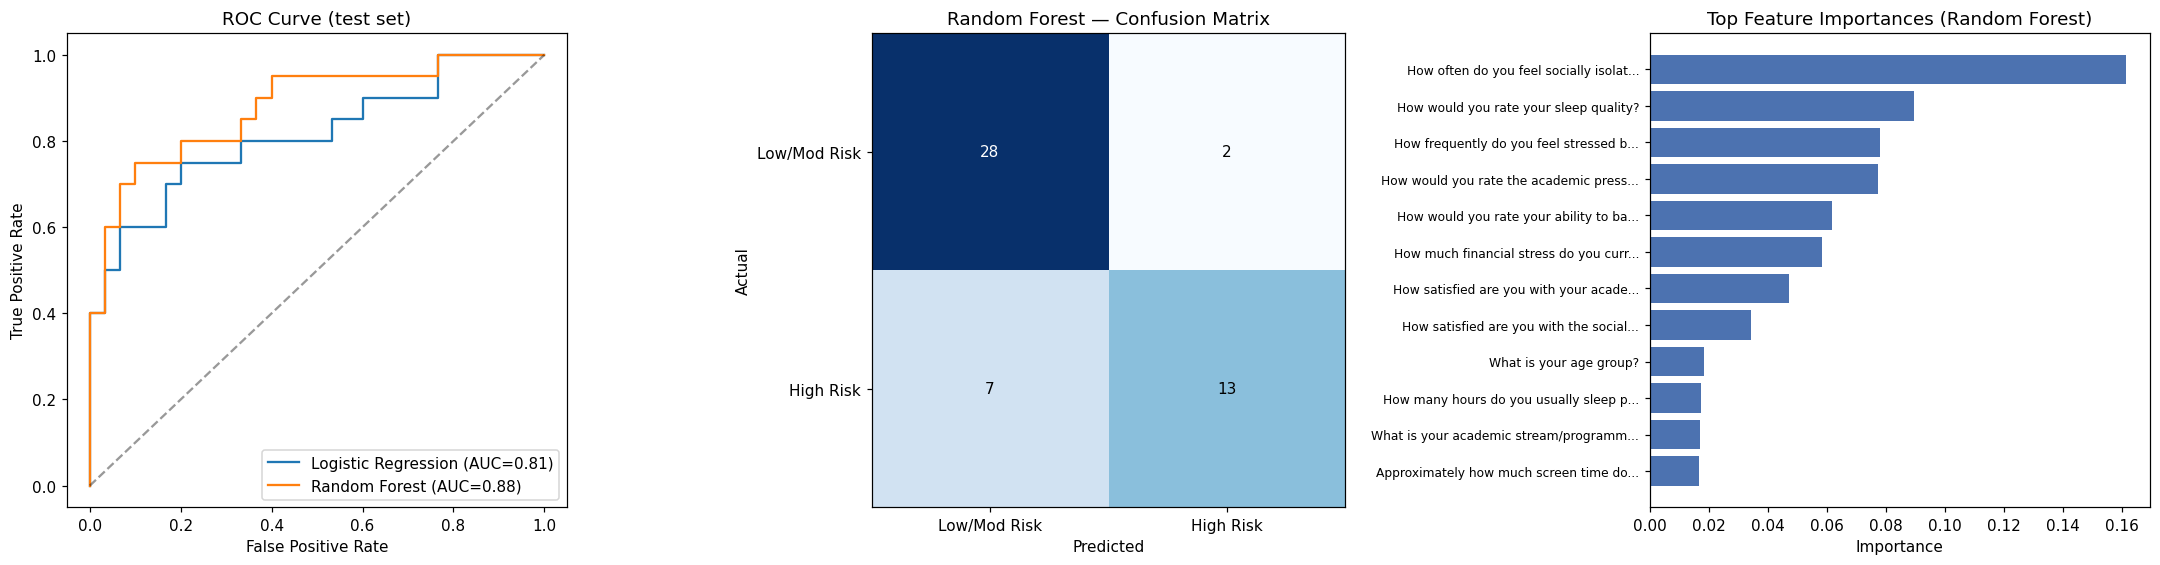

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (test set)")
axes[0].legend()

# Confusion matrix (Random Forest)
cm = results["Random Forest"]["confusion_matrix"]
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Low/Mod Risk", "High Risk"])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["Low/Mod Risk", "High Risk"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Random Forest — Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

# Feature importance
short_labels = []
for f in fi["feature"]:
    lbl = f.split(".", 1)[-1].strip() if f[:2].isdigit() is False and "." in f[:4] else f
    lbl = lbl.split("?")[0].strip() + "?" if "?" in lbl else lbl
    if len(lbl) > 40:
        lbl = lbl[:37] + "..."
    short_labels.append(lbl)

axes[2].barh(short_labels[::-1], fi["importance"][::-1], color="#4C72B0")
axes[2].set_title("Top Feature Importances (Random Forest)")
axes[2].set_xlabel("Importance")
axes[2].tick_params(axis="y", labelsize=8)

plt.tight_layout(pad=2.0)
plt.savefig("model_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Export Trained Pipeline

Save the fitted Random Forest pipeline plus metadata, so it can be reused
(e.g. by the companion Streamlit app) without retraining.

In [18]:
import joblib

final_pipe = Pipeline([("prep", preprocessor), ("clf", models["Random Forest"])])
final_pipe.fit(X, y)

artifact = {
    "pipeline": final_pipe,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "freq_map": FREQ_MAP,
    "feature_importance": fi.to_dict(orient="records"),
    "dataset_summary": {
        "n_rows": int(len(df)),
        "high_risk_rate": float(df["high_risk"].mean()),
    },
}

joblib.dump(artifact, "model_artifact.joblib")
print("Saved trained pipeline + metadata to model_artifact.joblib")

Saved trained pipeline + metadata to model_artifact.joblib


## 12. Limitations & Honest Caveats

- **Sample size.** After cleaning, this pipeline trains on roughly 190–200
  rows — small for machine learning. The 5-fold CV standard deviation
  (~0.05–0.07 AUC) reflects real instability: a different random seed or
  split can noticeably move these numbers.
- **The "High Risk" label is a self-report screening heuristic**, styled
  after real clinical screening tools (like the PHQ), but it has not been
  validated against an actual clinical diagnosis. It is a reasonable proxy,
  not ground truth.
- **Recall matters more than raw accuracy in a screening context** — missing
  an at-risk student (a false negative) is costlier than a false alarm. The
  current 0.5 decision threshold is not tuned for that; a real deployment
  would lower the threshold to favor recall.
- **Not a diagnostic tool.** This notebook produces a screening signal to
  help prioritize outreach, never a replacement for a conversation with a
  counsellor, doctor, or trusted adult.
- **Fairness.** Model performance has not been audited across demographic
  subgroups (age, gender, stream) — worth doing before any real-world use.